# HMS – Препроцесинг даних: покроковий огляд

Цей ноутбук проходить весь шлях від сирих файлів до тензора, який йде в модель.  
Кожен розділ — один ізольований крок пайплайну.

In [5]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pyarrow.parquet as pq
from pathlib import Path

DATA_DIR = Path('../data')
EEG_DIR  = DATA_DIR / 'train_eegs'

---
## Крок 1 — Завантаження train.csv і підрахунок голосів (`build_df`)

Вихідна таблиця має **106 800 рядків** — кожен рядок це одне 50-секундне анотаційне вікно.  
До них ми додаємо два похідні поля:

| Поле | Що робить |
|------|-----------|
| `n_votes` | Скільки лікарів проголосувало за це вікно (сума 6 vote-колонок, ≤ 6) |
| `expert_consensus` | Назва класу з найбільшою кількістю голосів (для стратифікації фолдів) |

In [6]:
from modelv3.dataset import VOTE_COLS, CLASS_NAMES, build_df

df = build_df(DATA_DIR / 'train.csv')
print(f'Рядків: {len(df):,}   Унікальних eeg_id: {df.eeg_id.nunique():,}')
df[['eeg_id', 'eeg_sub_id', 'n_votes', 'expert_consensus'] + VOTE_COLS].head()

Рядків: 106,800   Унікальних eeg_id: 17,089


,eeg_id,eeg_sub_id,n_votes,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,3,seizure,3,0,0,0,0,0
1,1628180742,1,3,seizure,3,0,0,0,0,0
2,1628180742,2,3,seizure,3,0,0,0,0,0
3,1628180742,3,3,seizure,3,0,0,0,0,0
4,1628180742,4,3,seizure,3,0,0,0,0,0


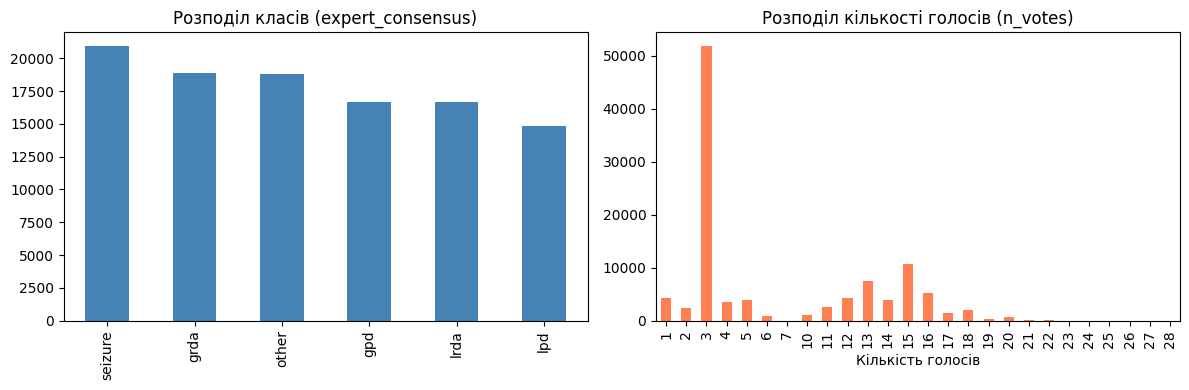

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['expert_consensus'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Розподіл класів (expert_consensus)')
axes[0].set_xlabel('')

df['n_votes'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Розподіл кількості голосів (n_votes)')
axes[1].set_xlabel('Кількість голосів')

plt.tight_layout()
plt.show()

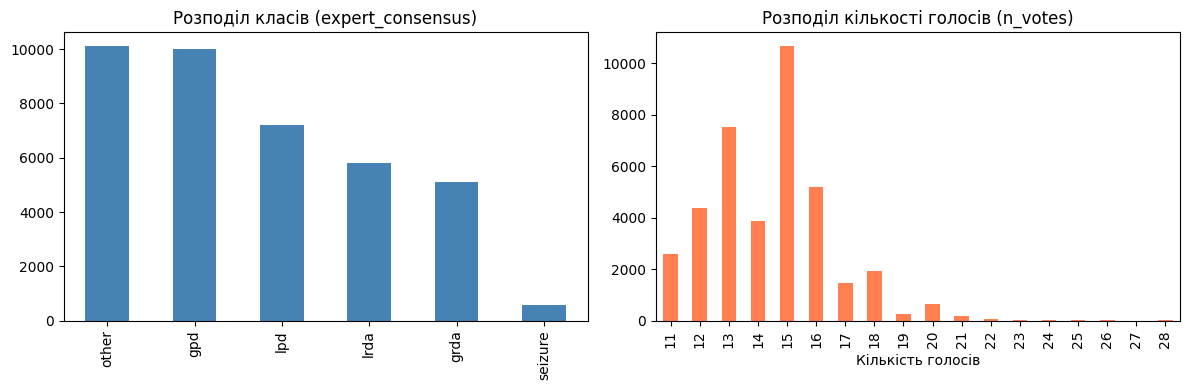

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_more10 = df[df['n_votes'] > 10]
df_more10['expert_consensus'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Розподіл класів (expert_consensus)')
axes[0].set_xlabel('')

df_more10['n_votes'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Розподіл кількості голосів (n_votes)')
axes[1].set_xlabel('Кількість голосів')

plt.tight_layout()
plt.show()

---
## Крок 2 — Розбиття на фолди (`make_folds`)

Використовується **StratifiedGroupKFold** (5 фолдів).  
Дві вимоги одночасно:
- **Stratify** по `expert_consensus` — класи рівномірно розподілені між фолдами
- **Group** по `patient_id` — всі вікна одного пацієнта потрапляють тільки в один фолд (немає витоку між train і val)

Фолд присвоюється на рівні `eeg_id`, потім розмножується на всі рядки цього eeg_id.

In [ ]:
from modelv3.dataset import make_folds

df = make_folds(df, n_splits=5, seed=42)

# Унікальні eeg_id per fold
fold_counts = df.drop_duplicates('eeg_id').groupby('fold')['expert_consensus'].value_counts().unstack(fill_value=0)
fold_counts.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab10')
plt.title('Кількість унікальних eeg_id по фолдах (стратифікація по класах)')
plt.xlabel('Fold')
plt.ylabel('Кількість eeg_id')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'coolz'

---
## Крок 3 — Читання parquet і вирізання вікна

Кожен `eeg_id` зберігається як окремий `.parquet` файл у `train_eegs/`.  
Файл може бути довшим за 50 сек — потрібний шматок вирізається за `eeg_label_offset_seconds`.

```
start_row = offset_sec × 200        # 200 Гц → 1 рядок = 5 мс
chunk     = raw[start_row : start_row + 10_000]   # рівно 50 сек
```

Читаємо тільки потрібні колонки (без EKG) щоб заощадити пам'ять.

In [ ]:
from modelv3.dataset import EEG_COLS, FS, WIN_SAMPLES

sample_row = df.iloc[0]
eeg_id     = int(sample_row['eeg_id'])
offset_sec = int(sample_row['eeg_label_offset_seconds'])

raw = pq.read_table(EEG_DIR / f'{eeg_id}.parquet', columns=EEG_COLS).to_pandas()
start = offset_sec * FS
chunk = raw.iloc[start: start + WIN_SAMPLES]

print(f'Файл:       {eeg_id}.parquet   — {len(raw):,} рядків ({len(raw)/FS:.0f} сек)')
print(f'Offset:     {offset_sec} сек  → рядки [{start}:{start+WIN_SAMPLES}]')
print(f'Вікно:      {chunk.shape}  ({WIN_SAMPLES/FS:.0f} сек, {len(EEG_COLS)} каналів)')

Файл:       1628180742.parquet   — 18,000 рядків (90 сек)
Offset:     0 сек  → рядки [0:10000]
Вікно:      (10000, 16)  (50 сек, 16 каналів)


---
## Крок 4 — Double Banana Montage (биполярний монтаж)

ЄЕГ записується 19 монополярними електродами (система 10–20).  
Ми конвертуємо їх у **16 биполярних каналів** ("Double Banana") — різниці між сусідніми електродами.  
Це стандарт у клінічній ЕЕГ-практиці і прибирає спільний шум.

```
sig[i] = electrode_A[i] - electrode_B[i]
```

4 ланцюги по 4 канали кожен:

| Ланцюг | Канали |
|--------|--------|
| LL (Left Lateral)      | Fp1–F7, F7–T3, T3–T5, T5–O1 |
| RL (Right Lateral)     | Fp2–F8, F8–T4, T4–T6, T6–O2 |
| LP (Left Parasagittal) | Fp1–F3, F3–C3, C3–P3, P3–O1 |
| RP (Right Parasagittal)| Fp2–F4, F4–C4, C4–P4, P4–O2 |

Форма після монтажу: (16, 10000)  (канали × семпли)


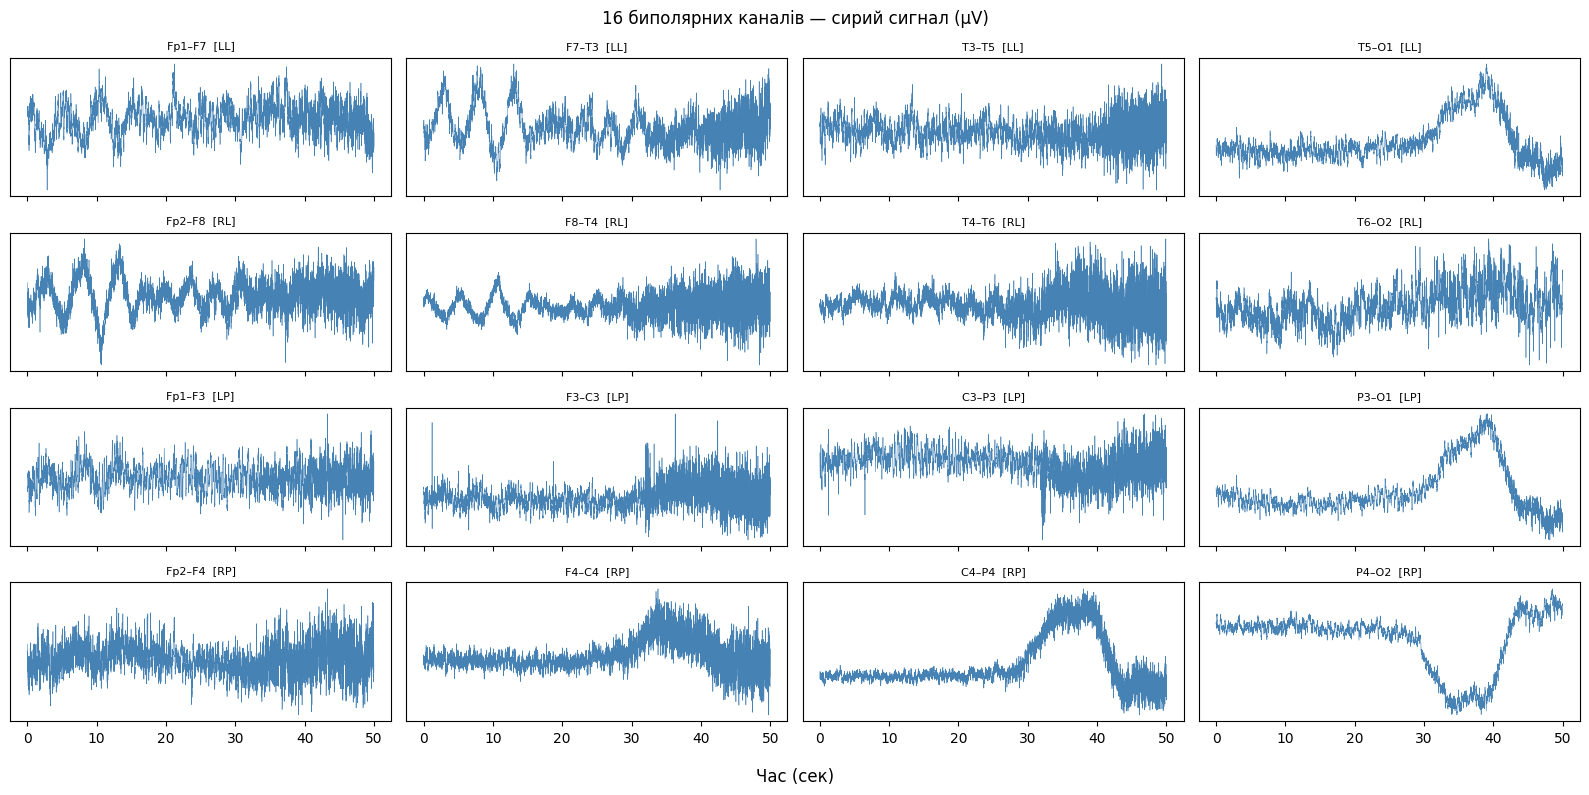

In [ ]:
from modelv3.dataset import DOUBLE_BANANA, N_CH

sig_raw = np.stack(
    [chunk[a].values - chunk[b].values for a, b in DOUBLE_BANANA], axis=0
).astype(np.float32)   # (16, 10000)

print(f'Форма після монтажу: {sig_raw.shape}  (канали × семпли)')

fig, axes = plt.subplots(4, 4, figsize=(16, 8), sharex=True)
chain_labels = ['LL']*4 + ['RL']*4 + ['LP']*4 + ['RP']*4
t = np.arange(WIN_SAMPLES) / FS

for i, (ax, (a, b)) in enumerate(zip(axes.flat, DOUBLE_BANANA)):
    ax.plot(t, sig_raw[i], lw=0.4, color='steelblue')
    ax.set_title(f'{a}–{b}  [{chain_labels[i]}]', fontsize=8)
    ax.set_yticks([])

fig.supxlabel('Час (сек)')
fig.suptitle('16 биполярних каналів — сирий сигнал (µV)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Крок 5 — NaN / Inf заміна, кліп і масштабування

Три послідовні операції над сирим сигналом:

1. **`nan_to_num`** — заміна NaN→0, +Inf→+1024, -Inf→-1024  
   *(ЕЕГ іноді має артефакти від відключення електроду)*

2. **`clip(-1024, +1024)`** — відрізаємо екстремальні сплески  
   *(великі артефакти руху/EM; нормальний ЕЕГ рідко перевищує ±200 µV)*

3. **`/ 32.0`** — масштабування → діапазон приблизно **[-32, +32]**  
   *(наближення до порядку величин, зручного для float32 і батч-норм)*

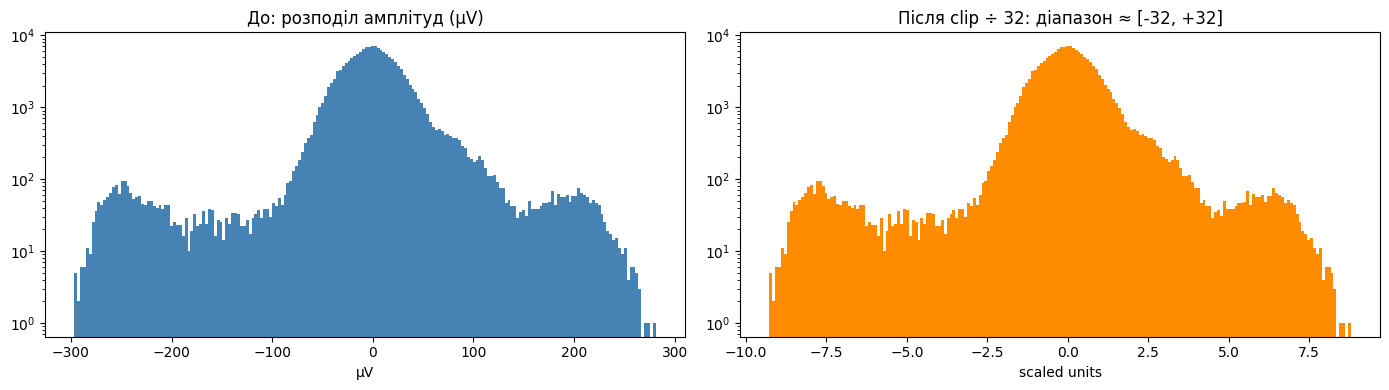

Сирий:     min=-296.7  max=281.4  µV
Scaled:    min=-9.273  max=8.792


In [ ]:
# Pad якщо вікно коротше (край файлу)
sig = sig_raw.copy()
if sig.shape[1] < WIN_SAMPLES:
    sig = np.pad(sig, ((0, 0), (0, WIN_SAMPLES - sig.shape[1])))

sig = np.nan_to_num(sig, nan=0.0, posinf=1024.0, neginf=-1024.0)
sig_clipped = np.clip(sig, -1024.0, 1024.0) / 32.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sig_raw.flatten(), bins=200, color='steelblue', log=True)
axes[0].set_title('До: розподіл амплітуд (µV)')
axes[0].set_xlabel('µV')

axes[1].hist(sig_clipped.flatten(), bins=200, color='darkorange', log=True)
axes[1].set_title('Після clip ÷ 32: діапазон ≈ [-32, +32]')
axes[1].set_xlabel('scaled units')

plt.tight_layout()
plt.show()

print(f'Сирий:     min={sig_raw.min():.1f}  max={sig_raw.max():.1f}  µV')
print(f'Scaled:    min={sig_clipped.min():.3f}  max={sig_clipped.max():.3f}')

---
## Крок 6 — Bandpass-фільтр (0.5 – 20 Гц)

**Butterworth 5-го порядку**, реалізований через SOS (second-order sections) для числової стабільності.

- **Нижня межа 0.5 Гц** — відрізає дуже повільний drift (артефакти руху, дихання, базова лінія)
- **Верхня межа 20 Гц** — відрізає high-frequency noise (м'язові артефакти, мережевий 50 Гц)  
  *(клінічно значуща ЕЕГ-активність лежить між 0.5–30 Гц; тут консервативно до 20 Гц)*

Фільтр застосовується до всіх 16 каналів одночасно (`axis=-1`).

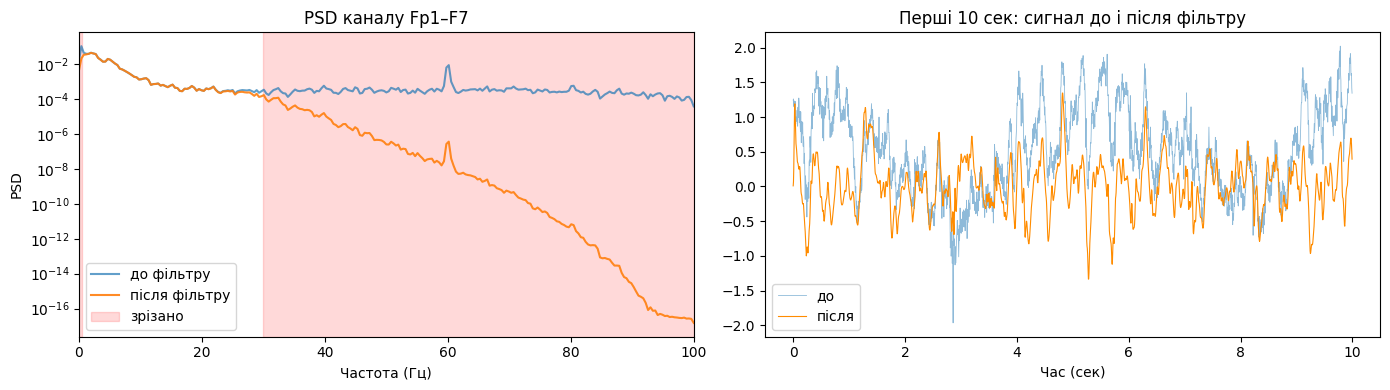

In [ ]:
from modelv3.dataset import _bandpass
from scipy.signal import welch

sig_filtered = _bandpass(sig_clipped, hi=30)  # (16, 10000)

# Порівняння PSD одного каналу до і після фільтра
ch = 0
f_raw, psd_raw = welch(sig_clipped[ch], fs=FS, nperseg=512)
f_fil, psd_fil = welch(sig_filtered[ch], fs=FS, nperseg=512)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(f_raw, psd_raw, label='до фільтру', alpha=0.7)
axes[0].semilogy(f_fil, psd_fil, label='після фільтру', alpha=0.9)
axes[0].axvspan(0, 0.5, alpha=0.15, color='red', label='зрізано')
axes[0].axvspan(30, FS/2, alpha=0.15, color='red')
axes[0].set_xlim(0, FS/2)
axes[0].set_title(f'PSD каналу {DOUBLE_BANANA[ch][0]}–{DOUBLE_BANANA[ch][1]}')
axes[0].set_xlabel('Частота (Гц)')
axes[0].set_ylabel('PSD')
axes[0].legend()

t = np.arange(WIN_SAMPLES) / FS
axes[1].plot(t[:2000], sig_clipped[ch, :2000], alpha=0.5, lw=0.6, label='до')
axes[1].plot(t[:2000], sig_filtered[ch, :2000], lw=0.8, label='після', color='darkorange')
axes[1].set_title('Перші 10 сек: сигнал до і після фільтру')
axes[1].set_xlabel('Час (сек)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Крок 7 — Перетворення сигналу в зображення (`_signals_to_image`)

Модель — 2D-CNN (EfficientNet), тому сигнал треба закодувати як зображення.  
Ідея: **3 темпоральні кропи різного масштабу** → 3 канали RGB.

### 7a. Три кропи часового вікна

| Канал | Довжина | Реальний час | Що показує |
|-------|---------|--------------|------------|
| 0 (R) | 2 000 семплів | 10 сек | Дрібні деталі, форми сплесків |
| 1 (G) | 5 000 семплів | 25 сек | Середня картина |
| 2 (B) | 10 000 семплів | 50 сек | Повне вікно, загальний паттерн |

### 7b. Reshape у 2D

Для кожного кропу: `(16 каналів, T семплів)` → `(160, T/10)` за допомогою `MICRO=10`

```
(16, T) → reshape(16, T//10, 10) → transpose(0,2,1) → reshape(160, T//10)
```

Тобто 10 послідовних семплів (~50 мс) «складаються» по висоті.  
Потім `cv2.resize` до `(1000, 160)` — всі 3 канали однакового розміру.

### 7c. Z-score нормалізація

```python
img = (img - img.mean()) / (img.std() + 1e-6)
```
Глобально по всьому тензору `(3, 160, 1000)` — всі канали в одному масштабі.

In [ ]:
sig_filtered

array([[ 8.0554215e-03,  6.4301983e-02,  2.3907839e-01, ...,
        -2.8750384e-01, -1.2140896e-01, -1.3355127e-02],
       [-6.4164121e-03, -5.0780348e-02, -1.8744110e-01, ...,
        -2.0483913e-01, -3.1270561e-01, -3.9123178e-01],
       [ 2.6568109e-03,  2.1236548e-02,  7.9011738e-02, ...,
        -1.9194538e-03,  4.4656657e-03,  5.4576006e-03],
       ...,
       [ 4.7126538e-03,  3.9041344e-02,  1.5001185e-01, ...,
        -1.5526743e-01,  9.4474502e-02,  5.9013322e-02],
       [-8.1141049e-04, -8.0328099e-03, -3.7034374e-02, ...,
        -9.6997595e-01, -1.1734896e+00, -1.1638430e+00],
       [-3.3589618e-04, -2.7052993e-03, -1.1351681e-02, ...,
         6.7259020e-01,  5.8572686e-01,  5.0233543e-01]],
      shape=(16, 10000), dtype=float32)

Форма зображення: (3, 160, 1000)  dtype=float32
Діапазон значень: [-6.96, 9.03]  (z-score)


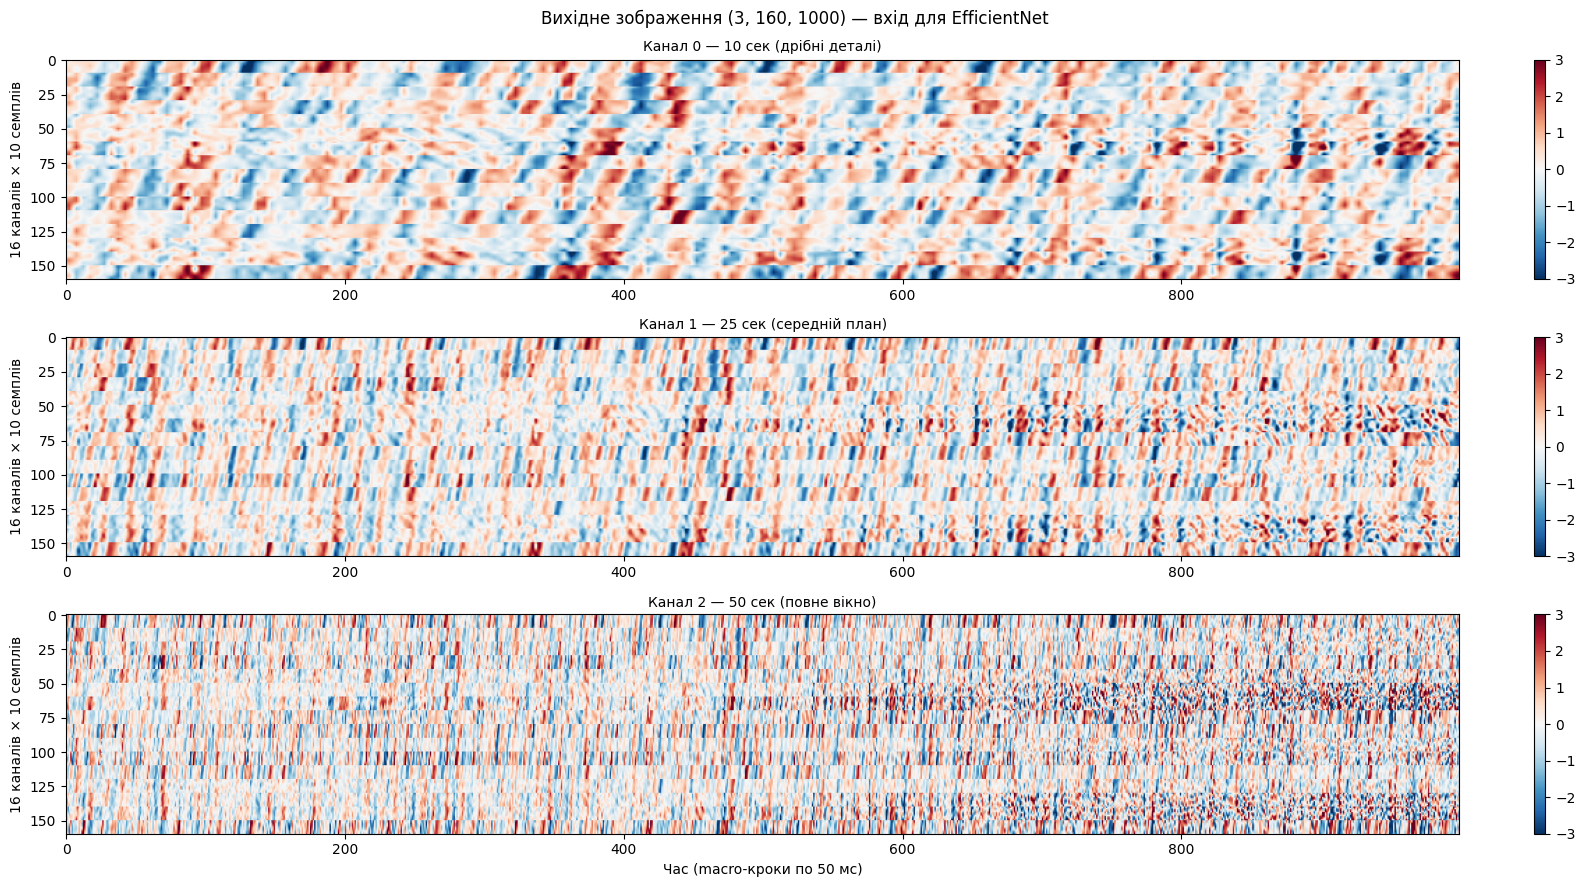

In [ ]:
from modelv3.dataset import _signals_to_image, CROP_LENGTHS, N_MACRO, MICRO

img = _signals_to_image(sig_filtered)  # (3, 160, 1000)
print(f'Форма зображення: {img.shape}  dtype={img.dtype}')
print(f'Діапазон значень: [{img.min():.2f}, {img.max():.2f}]  (z-score)')

channel_titles = [
    f'Канал 0 — {CROP_LENGTHS[0]//FS} сек (дрібні деталі)',
    f'Канал 1 — {CROP_LENGTHS[1]//FS} сек (середній план)',
    f'Канал 2 — {CROP_LENGTHS[2]//FS} сек (повне вікно)',
]

fig, axes = plt.subplots(3, 1, figsize=(16, 9))
for i, (ax, title) in enumerate(zip(axes, channel_titles)):
    im = ax.imshow(img[i], aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Час (macro-кроки по 50 мс)' if i == 2 else '')
    ax.set_ylabel('16 каналів × 10 семплів')
    plt.colorbar(im, ax=ax, fraction=0.02)

plt.suptitle('Вихідне зображення (3, 160, 1000) — вхід для EfficientNet', fontsize=12)
plt.tight_layout()
plt.show()

Вхід:   (16, 2000) → (16 каналів, 2000 семплів)
Крок 1: (16, 200, 10) → (16 каналів, 200 вікон по 10 семплів)
Крок 2: (16, 10, 200) → транспонуємо (16, 10, 200)
Крок 3: (160, 200) → з'єднуємо канали і мікро-кроки → висота 160


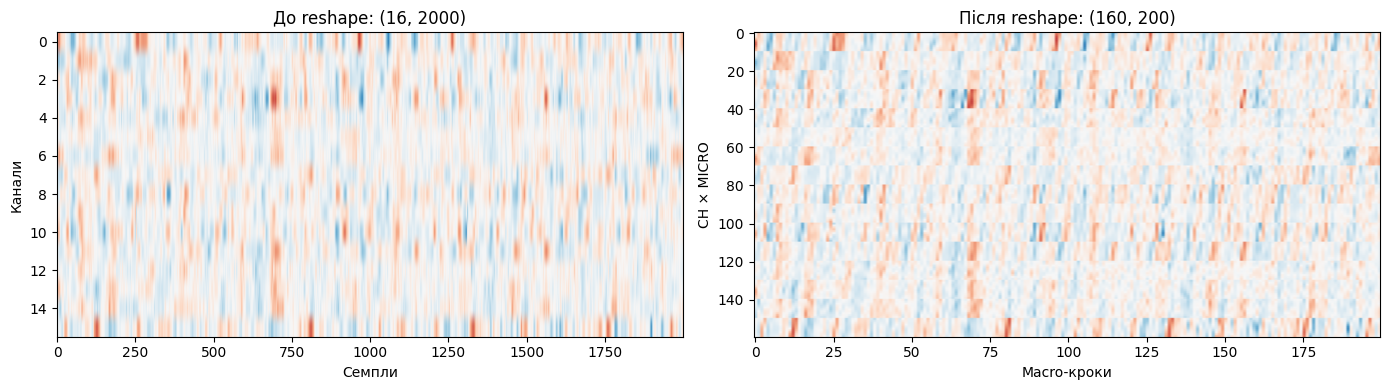

In [ ]:
# Пояснення reshape кроку
demo_sig = sig_filtered[:, :2000]   # один кроп: (16, 2000)
n = (demo_sig.shape[1] // MICRO) * MICRO  # 2000

step1 = demo_sig.reshape(N_CH, n // MICRO, MICRO)       # (16, 200, 10)
step2 = step1.transpose(0, 2, 1)                        # (16, 10, 200)
step3 = step2.reshape(N_CH * MICRO, n // MICRO)         # (160, 200)

print('Вхід:  ', demo_sig.shape, '→ (16 каналів, 2000 семплів)')
print('Крок 1:', step1.shape,    '→ (16 каналів, 200 вікон по 10 семплів)')
print('Крок 2:', step2.shape,    '→ транспонуємо (16, 10, 200)')
print('Крок 3:', step3.shape,    '→ з\'єднуємо канали і мікро-кроки → висота 160')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(demo_sig, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
axes[0].set_title('До reshape: (16, 2000)')
axes[0].set_xlabel('Семпли')
axes[0].set_ylabel('Канали')

axes[1].imshow(step3, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
axes[1].set_title('Після reshape: (160, 200)')
axes[1].set_xlabel('Macro-кроки')
axes[1].set_ylabel('CH × MICRO')

plt.tight_layout()
plt.show()

---
## Крок 8 — Агрегація міток і label smoothing

Одному `eeg_id` може відповідати кілька рядків (різні `eeg_sub_id`) з різними голосуваннями.  
Замість того щоб брати мітку одного рядку — **усереднюємо голоси по всіх вікнах** цього eeg_id.

```python
mean_votes = grp[VOTE_COLS].mean()   # середній вектор голосів
mean_votes += LABEL_SMOOTHING        # +0.005 до кожного класу
label = mean_votes / mean_votes.sum()  # нормалізуємо → розподіл імовірностей
```

**Label smoothing 0.005** — запобігає тому, щоб мережа була 100% впевнена в одному класі.  
Це покращує калібрацію — важливо для KL-divergence метрики.

eeg_id=1628180742 — 9 анотаційних вікон:


,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,eeg_sub_id,n_votes
0,3,0,0,0,0,0,0,3
1,3,0,0,0,0,0,1,3
2,3,0,0,0,0,0,2,3
3,3,0,0,0,0,0,3,3
4,3,0,0,0,0,0,4,3
5,3,0,0,0,0,0,5,3
6,3,0,0,0,0,0,6,3
7,3,0,0,0,0,0,7,3
8,3,0,0,0,0,0,8,3


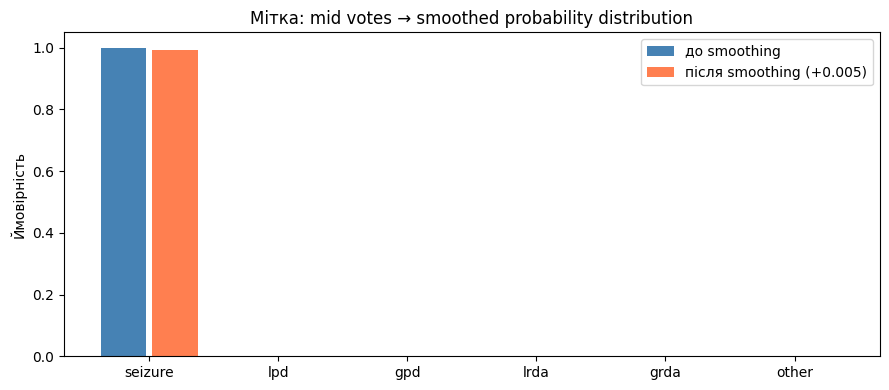

In [ ]:
from modelv3.dataset import LABEL_SMOOTHING

sample_eeg_id = df.iloc[0]['eeg_id']
grp = df[df['eeg_id'] == sample_eeg_id][VOTE_COLS + ['eeg_sub_id', 'n_votes']]

print(f'eeg_id={sample_eeg_id} — {len(grp)} анотаційних вікон:')
display(grp)

mean_votes = grp[VOTE_COLS].mean().values.astype(np.float32)
raw_label  = mean_votes / mean_votes.sum()

smoothed = mean_votes + LABEL_SMOOTHING
smoothed_label = smoothed / smoothed.sum()

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(CLASS_NAMES))
ax.bar(x - 0.2, raw_label, 0.35, label='до smoothing', color='steelblue')
ax.bar(x + 0.2, smoothed_label, 0.35, label='після smoothing (+0.005)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Мітка: mid votes → smoothed probability distribution')
ax.legend()
ax.set_ylabel('Ймовірність')
plt.tight_layout()
plt.show()

---
## Крок 9 — Вага семплу (`sample_weight`)

Не всі анотації однаково надійні. Запис де проголосували 2 лікарі гірше ніж де 6.

```python
weight = min(n_votes / 20.0, 1.0)
```

| n_votes | weight |
|---------|--------|
| 1       | 0.05   |
| 3       | 0.15   |
| 6       | 0.30   |
| 20+     | 1.00   |

Ця вага множиться на KL-loss при тренуванні **Stage 1** (де ми використовуємо всі дані).  
На **Stage 2** ми просто відфільтровуємо записи з `n_votes < 10` і ваги більше не потрібні.

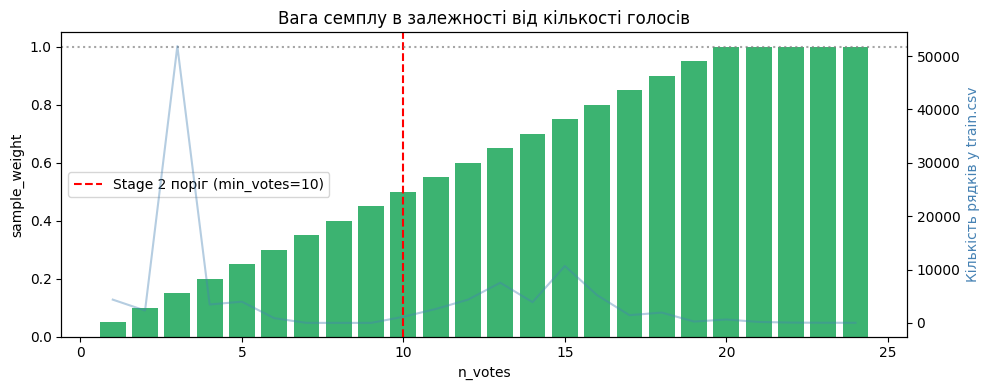

In [ ]:
votes_range = np.arange(1, 25)
weights = np.minimum(votes_range / 20.0, 1.0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(votes_range, weights, color='mediumseagreen')
ax.axvline(10, color='red', linestyle='--', label='Stage 2 поріг (min_votes=10)')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('n_votes')
ax.set_ylabel('sample_weight')
ax.set_title('Вага семплу в залежності від кількості голосів')
ax.legend()

# Реальний розподіл ваг
df['weight'] = df['n_votes'].apply(lambda v: min(v / 20.0, 1.0))
ax2 = ax.twinx()
df.groupby('n_votes').size().reindex(votes_range, fill_value=0).plot(
    kind='line', ax=ax2, color='steelblue', alpha=0.4, label='кількість рядків'
)
ax2.set_ylabel('Кількість рядків у train.csv', color='steelblue')

plt.tight_layout()
plt.show()

---
## Крок 10 — Аугментації (тільки train)

Два типи аугментацій застосовуються з ймовірністю 50%:

### 10a. Left–Right flip
Міняємо місцями ліву і праву півкулі:
```
LL (0-3) ↔ RL (4-7)   і   LP (8-11) ↔ RP (12-15)
```
ЕЕГ-паттерни (GPD, LPD та ін.) анатомічно симетричні — flip не змінює клінічний клас.

### 10b. Random temporal crop center
При побудові зображення (Крок 7) `center` вибирається **випадково** в межах  
`[2500, 7500]` семплів (щоб усі 3 кропи залишалися в межах 50-секундного вікна).  
Мережа вчиться розпізнавати патерн незалежно від його позиції у вікні.

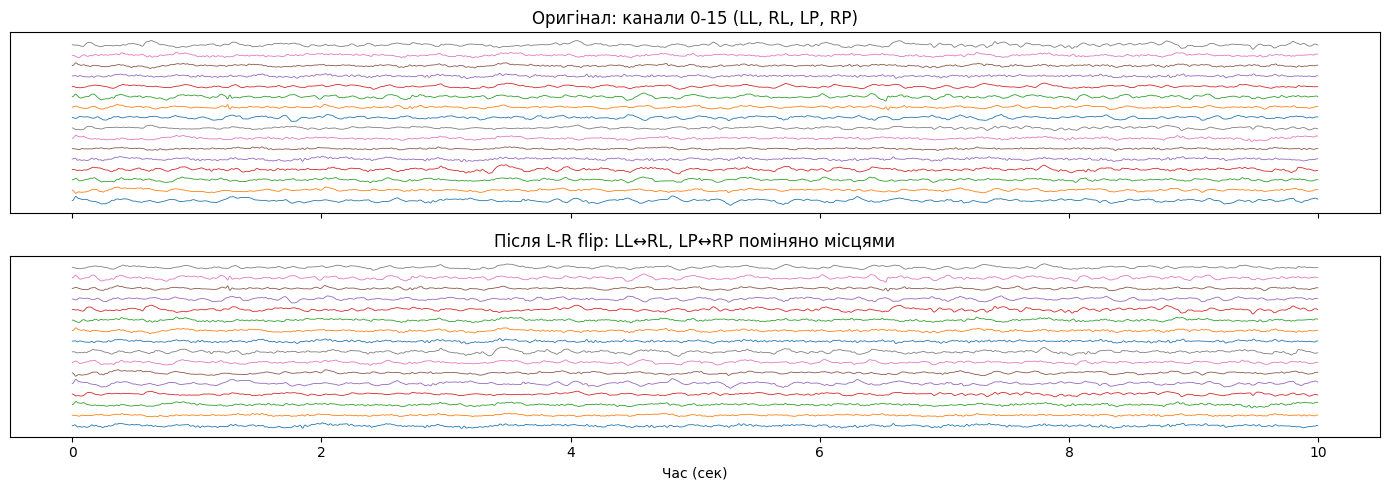

Приклади випадкових центрів кропу:
  center=4429  →  10s crop: [3429, 5429]  50s crop: [0, 10000]
  center=5278  →  10s crop: [4278, 6278]  50s crop: [0, 10000]
  center=4951  →  10s crop: [3951, 5951]  50s crop: [0, 10000]
  center=2665  →  10s crop: [1665, 3665]  50s crop: [0, 10000]
  center=5374  →  10s crop: [4374, 6374]  50s crop: [0, 10000]


In [ ]:
from modelv3.dataset import LR_FLIP
import random

# L-R flip
sig_flipped = sig_filtered[LR_FLIP]

chain_names = ['LL-0','LL-1','LL-2','LL-3','RL-0','RL-1','RL-2','RL-3',
               'LP-0','LP-1','LP-2','LP-3','RP-0','RP-1','RP-2','RP-3']

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t = np.arange(2000) / FS
for i in range(N_CH):
    offset = i * 3
    axes[0].plot(t, sig_filtered[i, :2000] + offset, lw=0.6, color=f'C{i%8}')
    axes[1].plot(t, sig_flipped[i, :2000] + offset, lw=0.6, color=f'C{i%8}')

axes[0].set_title('Оригінал: канали 0-15 (LL, RL, LP, RP)')
axes[1].set_title('Після L-R flip: LL↔RL, LP↔RP поміняно місцями')
axes[1].set_xlabel('Час (сек)')
for ax in axes:
    ax.set_yticks([])
plt.tight_layout()
plt.show()

# Random crop center
half = CROP_LENGTHS[1] // 2  # 2500
centers = [random.randint(half, WIN_SAMPLES - half) for _ in range(5)]
print('Приклади випадкових центрів кропу:')
for c in centers:
    print(f'  center={c}  →  10s crop: [{c-1000}, {c+1000}]  50s crop: [0, 10000]')

---
## Підсумок пайплайну

```
train.csv
  │
  ├─ build_df()          → +n_votes, +expert_consensus
  ├─ make_folds()        → +fold (StratifiedGroupKFold по patient_id)
  │
  └─ EEGDataset.__getitem__(idx)
       │
       ├─ _load(eeg_id, offset_sec)
       │    ├─ читаємо parquet (19→16 EEG_COLS)
       │    ├─ вирізаємо вікно 50 сек
       │    ├─ Double Banana монтаж → (16, 10000)
       │    ├─ pad / nan_to_num / clip±1024 / ÷32
       │    └─ bandpass 0.5–20 Гц (Butterworth 5)
       │
       ├─ [augment] LR flip з p=0.5
       ├─ [augment] random center crop
       │
       ├─ _signals_to_image(sig, center)
       │    ├─ 3 темпоральні кропи: 10s / 25s / 50s
       │    ├─ reshape (16, T) → (160, T//10)
       │    ├─ resize до (160, 1000)
       │    └─ z-score нормалізація → (3, 160, 1000)
       │
       ├─ label: mean votes по всіх sub-windows + smoothing 0.005 → softmax
       └─ weight: min(n_votes / 20, 1.0)

Вихід: (image: Tensor[3,160,1000], label: Tensor[6], weight: Tensor[])
```

In [ ]:
# Перевіримо весь пайплайн через EEGDataset
from modelv3.dataset import EEGDataset

fold_val = 0
val_df = df[df.fold == fold_val]
ds = EEGDataset(val_df, EEG_DIR, augment=False, min_votes=0)

img, label, weight = ds[0]
print(f'Dataset розмір: {len(ds)}')
print(f'img:    {tuple(img.shape)}  dtype={img.dtype}  range=[{img.min():.2f}, {img.max():.2f}]')
print(f'label:  {label.numpy().round(4)}  sum={label.sum():.4f}')
print(f'weight: {weight.item():.3f}')

print('\nРозподіл міток:')
for name, val in zip(CLASS_NAMES, label.numpy()):
    bar = '█' * int(val * 40)
    print(f'  {name:<8} {val:.4f}  {bar}')

Dataset розмір: 3419
img:    (3, 160, 1000)  dtype=torch.float32  range=[-4.87, 7.51]
label:  [0.2494 0.2494 0.0012 0.4975 0.0012 0.0012]  sum=1.0000
weight: 0.200

Розподіл міток:
  seizure  0.2494  █████████
  lpd      0.2494  █████████
  gpd      0.0012  
  lrda     0.4975  ███████████████████
  grda     0.0012  
  other    0.0012  
